In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To display plots properly
%matplotlib inline

In [33]:
df=pd.read_csv("/content/updated_screen_time_dataset (2).csv")

In [34]:
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.") #returns no.of rows and columns
df.columns  #returns what are the columns present in the dataset
print(df.dtypes)  #returns the datatypes

The dataset contains 9712 rows and 18 columns.
Age                                    int64
Gender                                object
Avg_Daily_Screen_Time_hr             float64
Primary_Device                        object
Exceeded_Recommended_Limit              bool
Educational_to_Recreational_Ratio    float64
Health_Impacts                        object
Urban_or_Rural                        object
Age_Band                              object
Device_Type_Category                  object
Screen_Time_Category                  object
weekday_flag                          object
Usage_Balance_Category                object
Health_Risk_Level                     object
Educational_Time_hr                  float64
Recreational_Time_hr                 float64
Educational_Time_Actual               object
Recreational_Time_Actual              object
dtype: object


In [35]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Device_Type_Category,Screen_Time_Category,weekday_flag,Usage_Balance_Category,Health_Risk_Level,Educational_Time_hr,Recreational_Time_hr,Educational_Time_Actual,Recreational_Time_Actual
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen,Portable,Moderate,weekday,Mostly Recreational,High Risk,1.180141,2.809859,1 hr 11 min,2 hr 49 min
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teen,Portable,High,weekend,Mostly Recreational,Moderate Risk,1.063846,3.546154,1 hr 4 min,3 hr 33 min
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Senior Teen,Other,Moderate,weekday,Mostly Recreational,Moderate Risk,0.904242,2.825758,0 hr 54 min,2 hr 50 min
3,15,Female,1.21,Laptop,False,0.39,No Health Impact,Urban,Teen,Portable,Low,weekday,Mostly Recreational,Moderate Risk,0.339496,0.870504,0 hr 20 min,0 hr 52 min
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teen,Portable,High,weekend,Mostly Recreational,High Risk,1.936980,3.953020,1 hr 56 min,3 hr 57 min


In [51]:
# create activity_type column
df['activity_type'] = ''

# assign values based on ratio
df.loc[df['Educational_to_Recreational_Ratio'] > 1, 'activity_type'] = 'Educational Usage'
df.loc[df['Educational_to_Recreational_Ratio'] < 1, 'activity_type'] = 'Recreational Usage'
df.loc[df['Educational_to_Recreational_Ratio'] == 1, 'activity_type'] = 'Balanced Usage'

# count of each activity type
counts = df['activity_type'].value_counts()
print(counts)

# total records
total = len(df)
print("Total Records:", total)

# percentage share of each activity type
activity_share = (counts / total) * 100
print(activity_share)


activity_type
Recreational Usage    9712
Name: count, dtype: int64
Total Records: 9712
activity_type
Recreational Usage    100.0
Name: count, dtype: float64


In [36]:
 #Verification of Categorical Consistencies

## Inconsistent Categories

print(df['Gender'].unique())
print(df['Primary_Device'].unique())
print(df['Exceeded_Recommended_Limit'].unique())
print(df['Urban_or_Rural'].unique())

['Male' 'Female']
['Smartphone' 'Laptop' 'TV' 'Tablet']
[ True False]
['Urban' 'Rural']


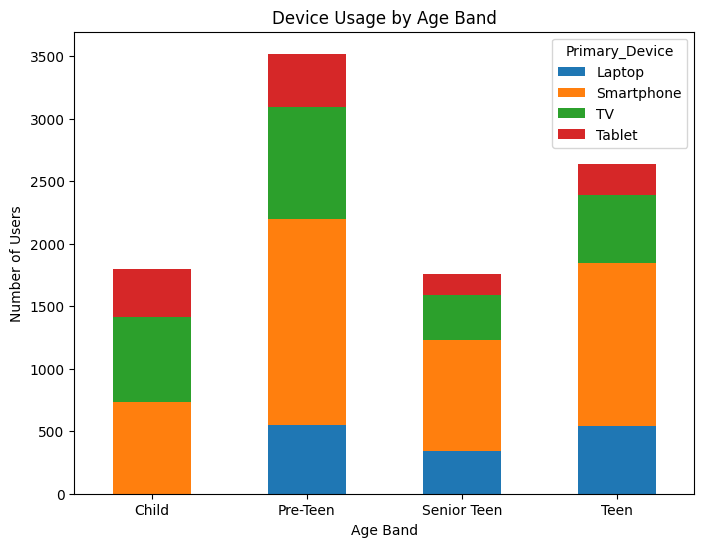

In [37]:
#Age Band × Device Type
cohort_device = pd.crosstab(df['Age_Band'], df['Primary_Device'])

cohort_device.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title("Device Usage by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.show()

Observation

The chart shows device usage distribution across different age bands.
Smartphones appear to be the most commonly used device among older children, particularly in the 13–15 age group.
Younger children rely more on tablets and television for screen activities.
This indicates that as children grow older, their preference shifts towards personal mobile devices.
The trend highlights increasing smartphone dependency with age.

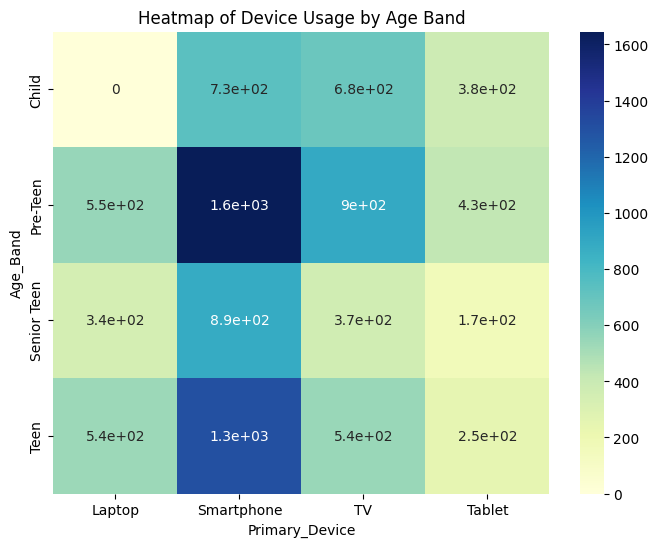

In [38]:
#Age Band × Device Heatmap
heatmap_data = pd.crosstab(df['Age_Band'], df['Primary_Device'])

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu")
plt.title("Heatmap of Device Usage by Age Band")
plt.show()


Obseravtion:

The heatmap clearly highlights smartphone dominance among older kids, while tablets are more common among younger cohorts.

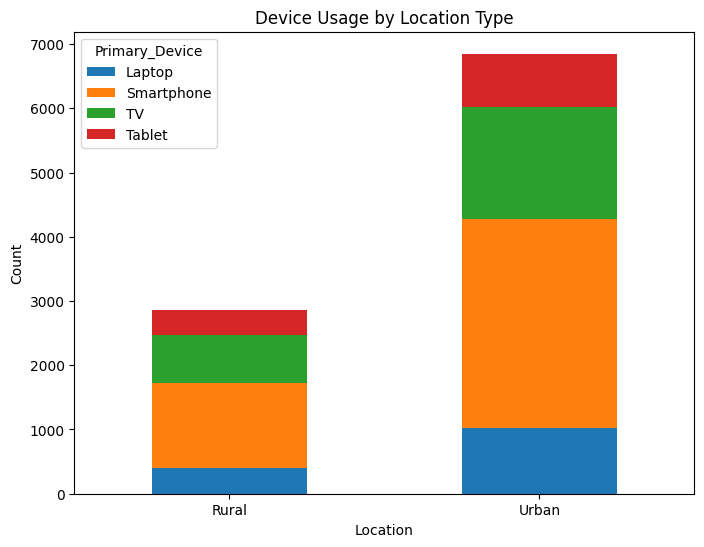

In [39]:
#Location × Device
location_device = pd.crosstab(df['Urban_or_Rural'], df['Primary_Device'])

location_device.plot(kind='bar', stacked=True, figsize=(8,6))
plt.title("Device Usage by Location Type")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


Observation:

Urban children show greater reliance on smartphones and tablets, while rural children demonstrate comparatively higher television usage.

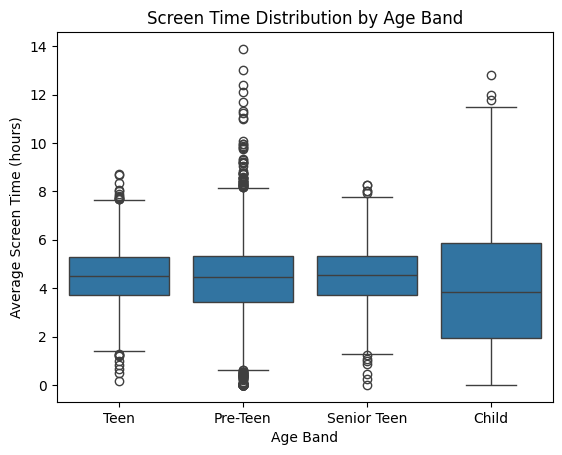

In [40]:
#Screen Time x Age
sns.boxplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time Distribution by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Average Screen Time (hours)")
plt.show()


Observation:

Screen time increases gradually with age, with teenagers showing the highest median screen time compared to younger cohorts.

Pre-Teen and Early Childhood invest most of the time as compared to Early Teen and Late Teen.

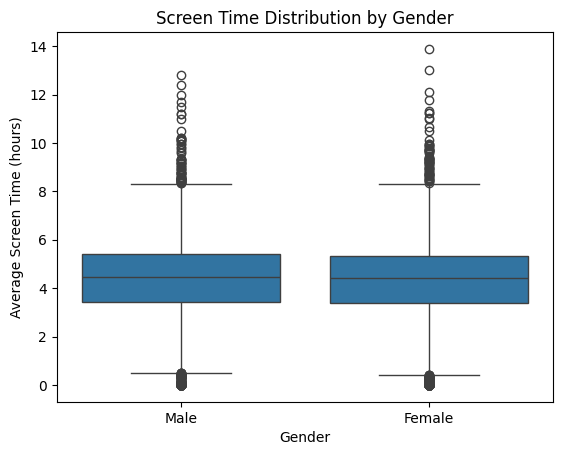

In [41]:
#Gender x Screen Time
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)

plt.title("Screen Time Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Screen Time (hours)")
plt.show()

Observation:

Screen time increases gradually with age, with teenagers showing the highest median screen time compared to younger cohorts.

Pre-Teen and Early Childhood invest most of the time as compared to Early Teen and Late Teen.

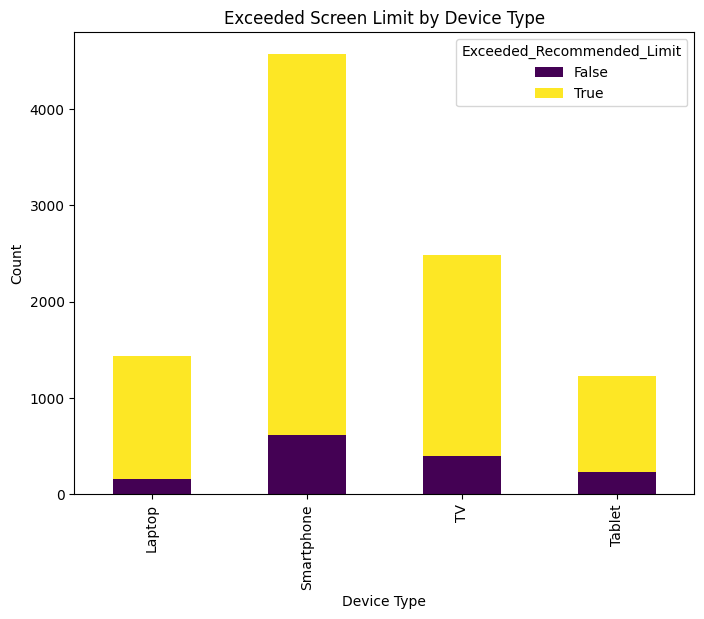

In [42]:
#Exceeded Limit × Device Type (Stacked Bar)
pd.crosstab(df['Primary_Device'], df['Exceeded_Recommended_Limit']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    colormap='viridis'
)

plt.title("Exceeded Screen Limit by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Count")
plt.show()

Portable devices like smartphones and tablets show the highest percentage of kids exceeding recommended screen time.

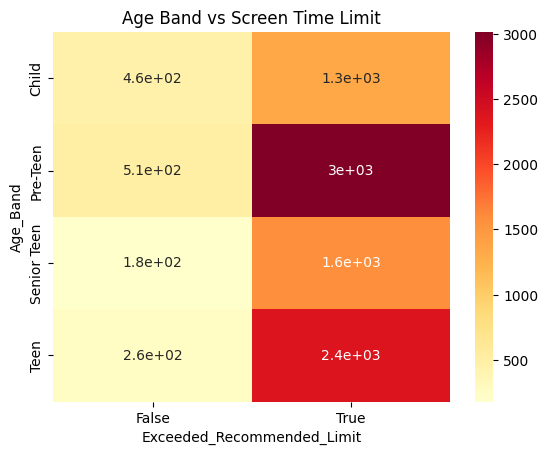

In [43]:
#Age Band × Exceeded Limit (Heatmap)
cohort = pd.crosstab(df['Age_Band'], df['Exceeded_Recommended_Limit'])

sns.heatmap(cohort, annot=True, cmap='YlOrRd')
plt.title("Age Band vs Screen Time Limit")
plt.show()

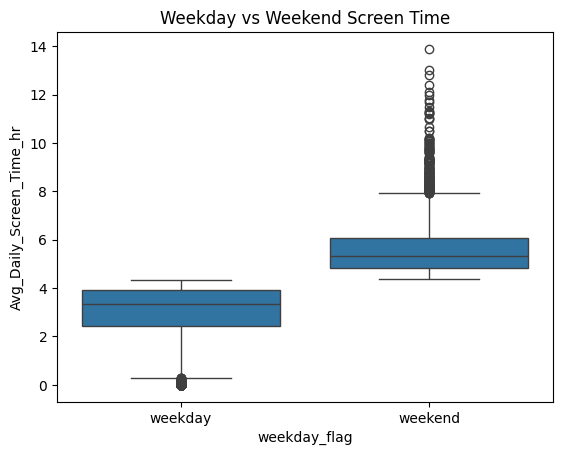

In [44]:
sns.boxplot(x='weekday_flag',
            y='Avg_Daily_Screen_Time_hr',
            data=df)

plt.title("Weekday vs Weekend Screen Time")
plt.show()

<Axes: xlabel='weekday_flag', ylabel='Avg_Daily_Screen_Time_hr'>

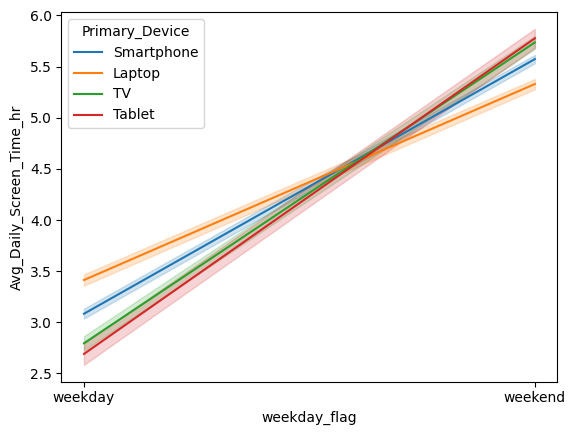

In [45]:
#Device Usage Trend by Time
sns.lineplot(data=df,
             x='weekday_flag',
             y='Avg_Daily_Screen_Time_hr',
             hue='Primary_Device')

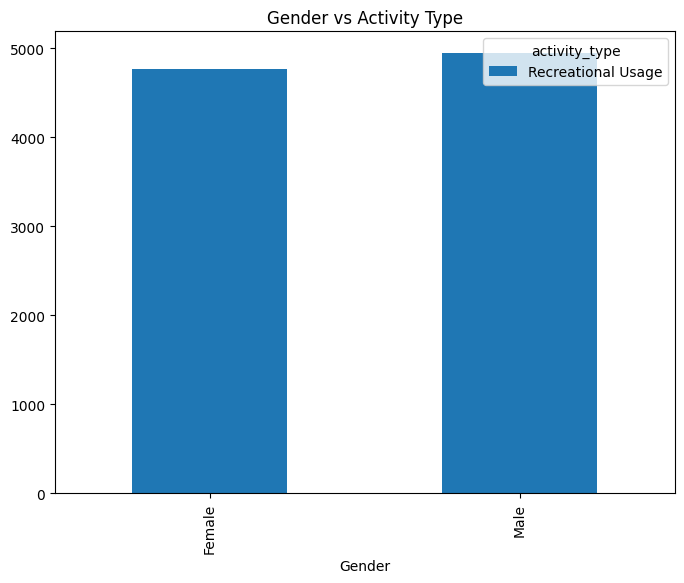

In [53]:
pd.crosstab(df['Gender'], df['activity_type']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)

plt.title("Gender vs Activity Type")
plt.show()

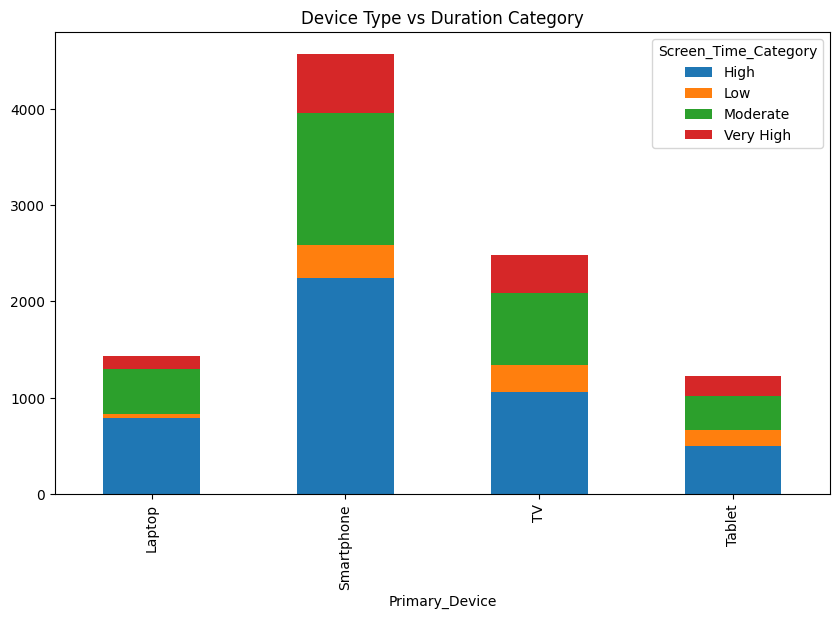

In [54]:
pd.crosstab(df['Primary_Device'], df['Screen_Time_Category']).plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Device Type vs Duration Category")
plt.show()

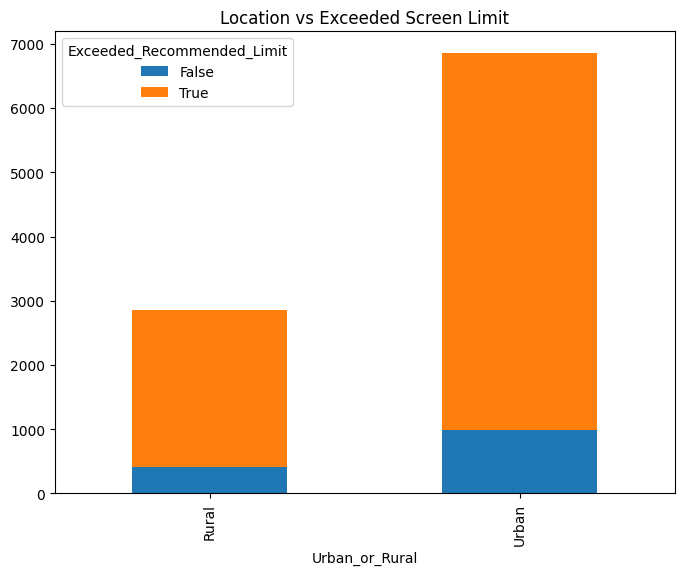

In [48]:
#Location × Exceeded Screen Limit
pd.crosstab(df['Urban_or_Rural'], df['Exceeded_Recommended_Limit']).plot(
    kind='bar',
    stacked=True,
    figsize=(8,6)
)

plt.title("Location vs Exceeded Screen Limit")
plt.show()

Key Cohort Findings

Teenagers (13–16 years) using smartphones represent the highest screen-time cohort.

Gaming and social media are the primary drivers of long-duration screen usage.

Urban children show higher screen time exposure compared to rural children.

Excessive screen usage is strongly associated with reported health issues such as eye strain and sleep problems.

Portable devices contribute significantly to extended daily screen exposure.